# Information Gain: Retriever Accuracy vs k (Synthesis Questions Only)

**Llama-3-8B-Instruct + GPT-4.1 Baselines**

This notebook measures **information gain** — how retriever accuracy changes as k increases —
using only the **30 Synthesis questions** from `QuestionBank_GreenandNew_90.xlsx`.

**Questions:** 30 Synthesis questions only (no DAC, no ChemCon)

**Baselines (k-independent, run once):**
- Abstract (gold-standard context)
- No context — Llama-3-8B-Instruct
- No context — GPT-4.1

**Retrievers (swept over k):**
- FAISS, MMR, BM25, Hybrid

**k values:** 5, 10, 15, 20, 25, 30

**Outputs:**
- Information gain line chart (accuracy vs k for each retriever, with baselines as horizontal lines)
- Results table and CSV export
- OOM / INVALID / ERROR summary at the end
- All plots saved as **SVG**

In [1]:
# Core imports
import os
import torch
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
import gc

# LangChain (for retrieval only) and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, pipeline

# OpenAI (for GPT-4.1 no_context baseline)
from openai import OpenAI
import httpx

# Load environment variables
with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            key, val = line[len('export '):].split('=', 1)
            os.environ[key] = val.strip('"').strip("'")

hf_token = os.environ.get("HF_TOKEN")

openai_key = os.environ.get("OPENAI_API_TOKEN")
if not openai_key:
    raise ValueError("OPENAI_API_TOKEN not found. Add it to /home/jupyter/Mrigi/env.sh.")
openai_client = OpenAI(api_key=openai_key, http_client=httpx.Client())
print("\u2713 OpenAI client initialized")

✓ OpenAI client initialized


In [2]:
!nvidia-smi

Tue Mar 10 17:53:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   40C    P0             67W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# Configuration
# ============================================================
MODELS = {
    'llama': {
        'name': 'meta-llama/Meta-Llama-3-8B-Instruct',
        'display_name': 'Llama-3-8B-Instruct',
        'gpu': 'cuda:3'
    }
}

K_VALUES = [5, 10, 15, 20, 25, 30]
RETRIEVAL_METHODS = ['faiss', 'mmr', 'bm25', 'hybrid']
BASELINE_METHODS = ['abstract', 'no_context', 'no_context_gpt41']

def load_model(model_key):
    config = MODELS[model_key]
    model_name = config['name']
    device = config['gpu']
    
    print(f"\n{'='*80}")
    print(f"Loading {config['display_name']} on {device}...")
    print(f"{'='*80}")
    
    tokenizer = AutoTokenizer.from_pretrained(
        model_name, trust_remote_code=True, use_fast=True, token=hf_token
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name, device_map=device, trust_remote_code=True,
        torch_dtype=torch.float16, token=hf_token
    )
    
    generation_config = GenerationConfig.from_pretrained(model_name)
    generation_config.max_new_tokens = 100
    generation_config.temperature = 0.1
    
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer,
                    generation_config=generation_config)
    llm = HuggingFacePipeline(pipeline=pipe)
    
    print(f"\u2713 {config['display_name']} loaded on {device}")
    return llm, model, tokenizer

print("\u2713 Configuration defined")

✓ Configuration defined


In [4]:
# ============================================================
# Prompt template and evaluation functions
# ============================================================
MC_PROMPT = """\nYou are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. \n\nProvide your answer in the following format EXACTLY:\nAnswer: [LETTER] - [One sentence explanation]\n\nFor example:\nAnswer: B - The synthesis temperature was increased to improve crystallization.\n\nChoose only from options A, B, C, D, or E.\nContext:\n{context}\n\nQuestion: {question}\n"""

NO_CONTEXT_PROMPT = """You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.\n\nProvide your answer in the following format EXACTLY:\nAnswer: [LETTER] - [One sentence explanation]\n\nFor example:\nAnswer: B - The synthesis temperature was increased to improve crystallization.\n\nChoose only from options A, B, C, D, or E.\n\nQuestion: {question}"""

def extract_completion(full_response, tokenizer):
    assistant_tag = "<|start_header_id|>assistant<|end_header_id|>"
    if assistant_tag in full_response:
        completion = full_response.split(assistant_tag)[-1].strip()
    else:
        completion = full_response.strip()
    for token in ["<|eot_id|>", "<|end_of_text|>"]:
        completion = completion.replace(token, "").strip()
    return completion

def parse_mc_answer(completion):
    last_answer_pos = completion.rfind("Answer: ")
    if last_answer_pos != -1:
        model_answer = completion[last_answer_pos + 8].upper()
        if model_answer in ['A', 'B', 'C', 'D', 'E']:
            explanation = ""
            answer_end = completion[last_answer_pos:].split('\n')[0]
            if '-' in answer_end:
                explanation = answer_end.split('-', 1)[1].strip()
            return model_answer, explanation
    return None, None

def evaluate_mc_response(llm, query, correct_answer, context, tokenizer):
    prompt_text = MC_PROMPT.format(context=context, question=query)
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    try:
        full_response = llm(formatted_prompt)
        completion = extract_completion(full_response, tokenizer)
        model_answer, explanation = parse_mc_answer(completion)
        if model_answer is not None:
            return {'query': query, 'context': context, 'model_answer': model_answer,
                    'correct_answer': correct_answer, 'is_correct': model_answer == correct_answer,
                    'full_response': completion, 'explanation': explanation or ""}
        return {'query': query, 'context': context, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'full_response': completion, 'error': 'No valid answer found'}
    except Exception as e:
        return {'query': query, 'context': context, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'error': f'Error: {str(e)}'}

def evaluate_mc_no_context(llm, query, correct_answer, tokenizer):
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    try:
        full_response = llm(formatted_prompt)
        completion = extract_completion(full_response, tokenizer)
        model_answer, explanation = parse_mc_answer(completion)
        if model_answer is not None:
            return {'query': query, 'model_answer': model_answer,
                    'correct_answer': correct_answer, 'is_correct': model_answer == correct_answer,
                    'full_response': completion, 'explanation': explanation or ""}
        return {'query': query, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'full_response': completion, 'error': 'No valid answer found'}
    except Exception as e:
        return {'query': query, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'error': f'Error: {str(e)}'}

def evaluate_mc_no_context_gpt41(query, correct_answer):
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    try:
        response = openai_client.chat.completions.create(
            model="gpt-4.1",
            messages=[{"role": "user", "content": prompt_text}],
            temperature=0.1, max_tokens=150
        )
        completion = response.choices[0].message.content.strip()
        model_answer, explanation = parse_mc_answer(completion)
        if model_answer is not None:
            return {'query': query, 'model_answer': model_answer,
                    'correct_answer': correct_answer, 'is_correct': model_answer == correct_answer,
                    'full_response': completion, 'explanation': explanation or ""}
        return {'query': query, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'full_response': completion, 'error': 'No valid answer found'}
    except Exception as e:
        print(f"GPT-4.1 error: {str(e)}")
        return {'query': query, 'model_answer': 'INVALID',
                'correct_answer': correct_answer, 'is_correct': False,
                'error': f'GPT-4.1 API error: {str(e)}'}

print("\u2713 Evaluation functions defined")

✓ Evaluation functions defined


In [5]:
# ============================================================
# Retrieval functions
# ============================================================
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever, EnsembleRetriever
from pathlib import Path

embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"
if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(INDEX_DIRECTORY, embeddings, index_name=INDEX_NAME,
                              allow_dangerous_deserialization=True)
faiss_retriever = vector_db.as_retriever(search_kwargs={"k": 10})
print(f"\u2713 Loaded vector database with {vector_db.index.ntotal} vectors")

all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"\u2713 BM25 retriever initialized with {len(all_docs)} documents")

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever], weights=[0.5, 0.5]
)
print("\u2713 Ensemble retriever defined")

def get_faiss_context(query, k=10):
    results = vector_db.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_mmr_context(query, k=10):
    results = vector_db.max_marginal_relevance_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_bm25_context(query, k=10):
    results = bm25_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_hybrid_context(query, k=10):
    results = ensemble_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

print("\u2713 Retrieval context functions defined")

/tmp/ipykernel_578601/159375820.py:9: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database with 1474439 vectors
✓ BM25 retriever initialized with 1474439 documents
✓ Ensemble retriever defined
✓ Retrieval context functions defined
✓ BM25 retriever initialized with 1474439 documents
✓ Ensemble retriever defined
✓ Retrieval context functions defined


In [6]:
# ============================================================
# Unified evaluate_method function
# ============================================================
def evaluate_method(llm, method_name, questions_df, tokenizer, k=10):
    """
    Evaluate a retrieval method on all questions.
    Clears GPU cache after each question to prevent OOM.
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df),
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        try:
            if method_name == 'abstract':
                context = row['Context']
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'no_context':
                result = evaluate_mc_no_context(llm, query, correct_answer, tokenizer)
            elif method_name == 'no_context_gpt41':
                result = evaluate_mc_no_context_gpt41(query, correct_answer)
            elif method_name == 'faiss':
                context = get_faiss_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'mmr':
                context = get_mmr_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'bm25':
                context = get_bm25_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'hybrid':
                context = get_hybrid_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            else:
                raise ValueError(f"Unknown method: {method_name}")
        except Exception as e:
            print(f"  \u26a0 Error on question: {str(e)[:100]}")
            result = {'query': query, 'model_answer': 'ERROR',
                      'correct_answer': correct_answer, 'is_correct': False,
                      'error': str(e)}
        
        results.append(result)
        gc.collect()
        torch.cuda.empty_cache()
    
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name, 'k': k,
        'accuracy': accuracy, 'correct_count': correct_count, 'total': total,
        'detailed_results': results
    }

print("\u2713 evaluate_method defined")

✓ evaluate_method defined


In [7]:
# ============================================================
# Load Synthesis questions ONLY (30 questions)
# ============================================================
QUESTION_FILE = 'QuestionBank_GreenandNew_90.xlsx'

df = pd.read_excel(QUESTION_FILE, sheet_name='Synthesis')
df = df.dropna(subset=['gpt_generated_question'])
df = df.rename(columns={
    'gpt_generated_question': 'Question',
    'gpt_generated_answer': 'Correct_Answer',
    'abstract': 'Context'
})
df['Correct_Answer'] = df['Correct_Answer'].str.strip().str.upper()
synthesis_df = df

print(f"\u2713 Loaded {len(synthesis_df)} Synthesis questions")
print(f"  Answer distribution: {synthesis_df['Correct_Answer'].value_counts().to_dict()}")

✓ Loaded 30 Synthesis questions
  Answer distribution: {'B': 13, 'C': 8, 'A': 7, 'D': 2}


## Load Model and Run Baselines

Run the 3 k-independent baselines once: Abstract, No Context (Llama), No Context (GPT-4.1).

In [8]:
# ============================================================
# Load model + run baselines (k-independent)
# ============================================================
all_results = {}  # all_results[method][k] = {accuracy, correct_count, total, detailed_results}
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

llm, model, tokenizer = load_model('llama')
model_display_name = MODELS['llama']['display_name']

print(f"\n{'='*80}")
print(f"Running baselines on {len(synthesis_df)} Synthesis questions")
print(f"{'='*80}")

for method in BASELINE_METHODS:
    print(f"\n--- {method.upper()} ---")
    result = evaluate_method(llm, method, synthesis_df, tokenizer, k=0)
    all_results[method] = {'baseline': result}
    print(f"\u2713 {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")

# Save intermediate
temp_path = f'results_23f_complete_{timestamp}.json'
with open(temp_path, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print(f"\n\u2713 Baselines complete. Saved to {temp_path}")


Loading Llama-3-8B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/utils/hub.py:374: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/tmp/ipykernel_578601/1796400332.py:39: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


✓ Llama-3-8B-Instruct loaded on cuda:3

Running baselines on 30 Synthesis questions

--- ABSTRACT ---


...

✓ 100.00% (30/30)

--- NO_CONTEXT ---


Evaluating no_context (k=0):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order t

✓ 86.67% (26/30)

--- NO_CONTEXT_GPT41 ---


Evaluating no_context_gpt41 (k=0): 100%|██████████| 30/30 [01:40<00:00,  3.36s/it]

✓ 90.00% (27/30)

✓ Baselines complete. Saved to results_23f_complete_20260310_175525.json


## Information Gain: Sweep k = 5, 10, 15, 20, 25, 30

Run all 4 retrieval methods (FAISS, MMR, BM25, Hybrid) at each k value.

In [9]:
# ============================================================
# Sweep k values for all 4 retrieval methods
# ============================================================
for method in RETRIEVAL_METHODS:
    if method not in all_results:
        all_results[method] = {}

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"k = {k}")
    print(f"{'='*80}")
    
    torch.cuda.empty_cache()
    gc.collect()
    
    for method in RETRIEVAL_METHODS:
        print(f"\n--- {method.upper()} | k={k} ({len(synthesis_df)} questions) ---")
        
        try:
            result = evaluate_method(llm, method, synthesis_df, tokenizer, k=k)
            all_results[method][k] = result
            print(f"\u2713 {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
        except Exception as e:
            print(f"\u2717 Error: {str(e)}")
            all_results[method][k] = {
                'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0,
                'detailed_results': []
            }
    
    # Save after each k
    temp_path = f'results_23f_complete_{timestamp}.json'
    with open(temp_path, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
    print(f"\u2713 Saved to {temp_path} ({os.path.getsize(temp_path)/(1024*1024):.1f} MB)")

print(f"\n{'='*80}")
print(f"All k-value sweeps complete!")
print(f"{'='*80}")


k = 5

--- FAISS | k=5 (30 questions) ---


Evaluating faiss (k=5):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to max

✓ 90.00% (27/30)

--- MMR | k=5 (30 questions) ---


Evaluating mmr (k=5):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxim

✓ 93.33% (28/30)

--- BM25 | k=5 (30 questions) ---


...

✓ 80.00% (24/30)

--- BM25 | k=30 (30 questions) ---


Evaluating bm25 (k=30):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to max

✓ 86.67% (26/30)

--- HYBRID | k=30 (30 questions) ---


Evaluating hybrid (k=30):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m

✓ 90.00% (27/30)
✓ Saved to results_23f_complete_20260310_175525.json (17.0 MB)

All k-value sweeps complete!


## Results Table

In [10]:
# ============================================================
# Print results table
# ============================================================
print("\n" + "="*100)
print("INFORMATION GAIN RESULTS: Synthesis Questions (n=30)")
print("="*100)

# Baselines
print(f"\n{'--- Baselines (k-independent) ---':}")
print(f"{'Method':<20} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*50)
for m in BASELINE_METHODS:
    r = all_results[m]['baseline']
    print(f"{m:<20} {r['accuracy']:>6.2f}%      {r['correct_count']}/{r['total']}")

# Retrieval methods across k
print(f"\n{'--- Retrieval Methods across k ---':}")
header = f"{'Method':<12}"
for k in K_VALUES:
    header += f" {'k='+str(k):>8}"
print(header)
print("-"*75)

for m in RETRIEVAL_METHODS:
    row = f"{m:<12}"
    for k in K_VALUES:
        r = all_results[m].get(k, {})
        acc = r.get('accuracy', 0)
        row += f" {acc:>7.2f}%"
    print(row)

print("="*100)


INFORMATION GAIN RESULTS: Synthesis Questions (n=30)

--- Baselines (k-independent) ---
Method               Accuracy     Correct/Total  
--------------------------------------------------
abstract             100.00%      30/30
no_context            86.67%      26/30
no_context_gpt41      90.00%      27/30

--- Retrieval Methods across k ---
Method            k=5     k=10     k=15     k=20     k=25     k=30
---------------------------------------------------------------------------
faiss          90.00%   90.00%   96.67%   80.00%   40.00%   23.33%
mmr            93.33%   96.67%   96.67%   80.00%   80.00%   80.00%
bm25           83.33%   90.00%   86.67%   86.67%   86.67%   86.67%
hybrid         90.00%   96.67%   96.67%   90.00%   90.00%   90.00%


## Information Gain Plot

Line chart: accuracy vs k for each retriever, with baselines as horizontal dashed lines.

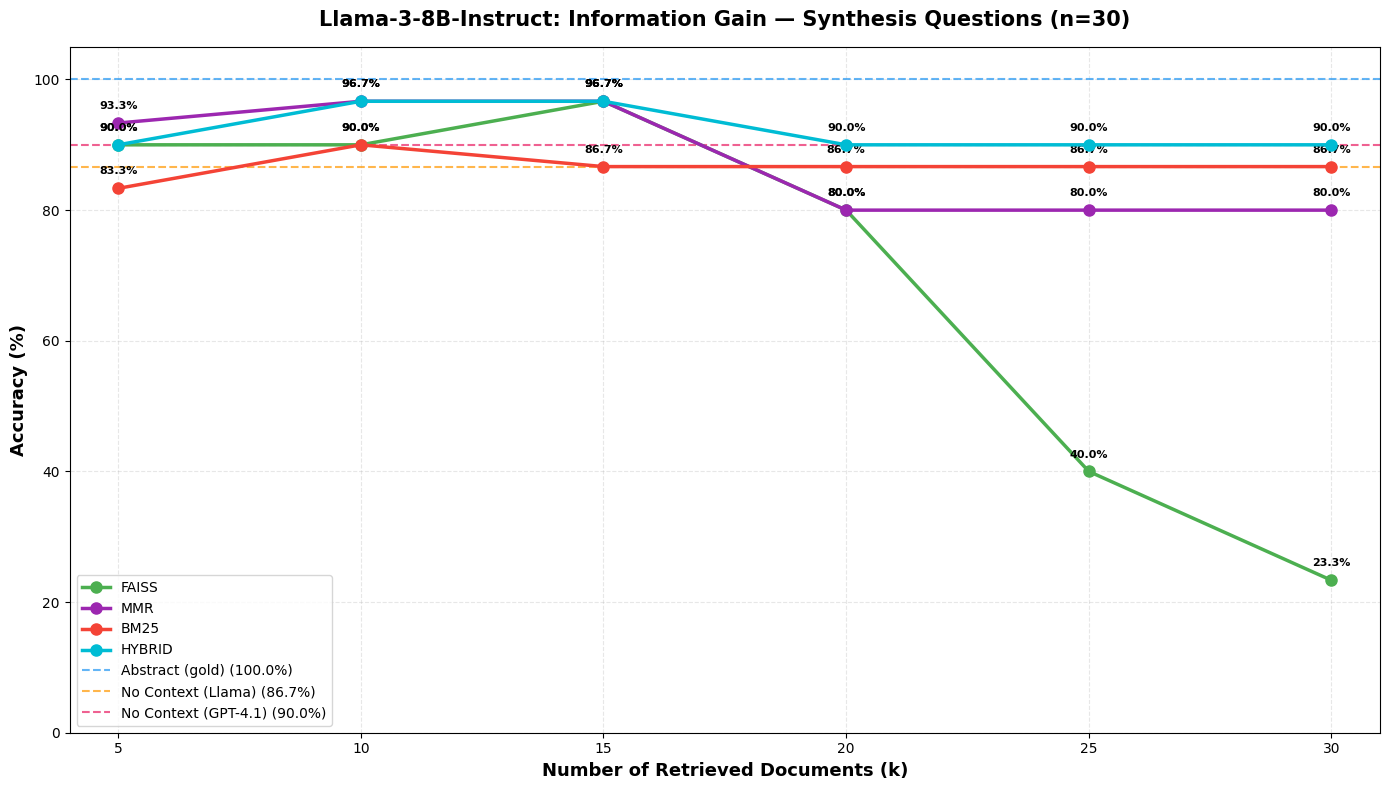

✓ Information gain plot saved as information_gain_synthesis_20260310_175525.svg


In [11]:
# ============================================================
# Information Gain Line Chart
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

retrieval_colors = {
    'faiss': '#4CAF50', 'mmr': '#9C27B0', 'bm25': '#F44336', 'hybrid': '#00BCD4'
}
baseline_colors = {
    'abstract': '#2196F3', 'no_context': '#FF9800', 'no_context_gpt41': '#E91E63'
}
baseline_labels = {
    'abstract': 'Abstract (gold)', 'no_context': 'No Context (Llama)',
    'no_context_gpt41': 'No Context (GPT-4.1)'
}

fig, ax = plt.subplots(figsize=(14, 8))

# Plot retriever lines
for method in RETRIEVAL_METHODS:
    accs = [all_results[method].get(k, {}).get('accuracy', 0) for k in K_VALUES]
    ax.plot(K_VALUES, accs, marker='o', linewidth=2.5, markersize=8,
            color=retrieval_colors[method], label=method.upper(), zorder=3)
    # Annotate each point
    for k_val, acc in zip(K_VALUES, accs):
        ax.annotate(f'{acc:.1f}%', (k_val, acc), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=8, fontweight='bold')

# Plot baselines as horizontal dashed lines
for m in BASELINE_METHODS:
    acc = all_results[m]['baseline']['accuracy']
    ax.axhline(y=acc, color=baseline_colors[m], linestyle='--', linewidth=1.5,
               alpha=0.7, label=f"{baseline_labels[m]} ({acc:.1f}%)")

ax.set_xlabel('Number of Retrieved Documents (k)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title(f'{model_display_name}: Information Gain — Synthesis Questions (n=30)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(K_VALUES)
ax.set_xlim(K_VALUES[0] - 1, K_VALUES[-1] + 1)
ax.set_ylim(0, 105)
ax.legend(loc='best', frameon=True, fontsize=10)
ax.grid(axis='both', alpha=0.3, linestyle='--')

plt.tight_layout()
fig.savefig(f'information_gain_synthesis_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()
print(f"\u2713 Information gain plot saved as information_gain_synthesis_{timestamp}.svg")

## Export Results to CSV

In [12]:
# ============================================================
# Export to CSV
# ============================================================
export_rows = []

# Baselines
for m in BASELINE_METHODS:
    r = all_results[m]['baseline']
    export_rows.append({
        'model': model_display_name, 'method': m, 'k': 'baseline',
        'accuracy': r['accuracy'], 'correct': r['correct_count'], 'total': r['total']
    })

# Retrieval methods
for m in RETRIEVAL_METHODS:
    for k in K_VALUES:
        r = all_results[m].get(k, {})
        export_rows.append({
            'model': model_display_name, 'method': m, 'k': k,
            'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0),
            'total': r.get('total', 0)
        })

export_df = pd.DataFrame(export_rows)
csv_path = f'results_23f_info_gain_{timestamp}.csv'
export_df.to_csv(csv_path, index=False)
print(f"\u2713 Exported to {csv_path}")
print(export_df.to_string(index=False))

✓ Exported to results_23f_info_gain_20260310_175525.csv
              model           method        k   accuracy  correct  total
Llama-3-8B-Instruct         abstract baseline 100.000000       30     30
Llama-3-8B-Instruct       no_context baseline  86.666667       26     30
Llama-3-8B-Instruct no_context_gpt41 baseline  90.000000       27     30
Llama-3-8B-Instruct            faiss        5  90.000000       27     30
Llama-3-8B-Instruct            faiss       10  90.000000       27     30
Llama-3-8B-Instruct            faiss       15  96.666667       29     30
Llama-3-8B-Instruct            faiss       20  80.000000       24     30
Llama-3-8B-Instruct            faiss       25  40.000000       12     30
Llama-3-8B-Instruct            faiss       30  23.333333        7     30
Llama-3-8B-Instruct              mmr        5  93.333333       28     30
Llama-3-8B-Instruct              mmr       10  96.666667       29     30
Llama-3-8B-Instruct              mmr       15  96.666667       29   

## OOM / INVALID / ERROR Summary

Check every question across every method and k value for non-valid answers (INVALID, ERROR, OOM).

In [13]:
# ============================================================
# OOM / INVALID / ERROR Summary
# ============================================================
print("="*120)
print("OOM / INVALID / ERROR SUMMARY")
print("Counts questions where the model returned INVALID or ERROR instead of A-E")
print("="*120)

grand_total_q = 0
grand_total_invalid = 0
grand_total_error = 0
error_details = []  # collect (method, k, question_idx, query_snippet, error_msg)

print(f"\n{'Method':<20} {'k':<10} {'Total Q':<10} {'Invalid':<10} {'Error/OOM':<10} {'Valid %':<10}")
print("-"*75)

# Baselines
for m in BASELINE_METHODS:
    detailed = all_results[m]['baseline'].get('detailed_results', [])
    total_q = len(detailed)
    n_invalid = sum(1 for r in detailed if r.get('model_answer') == 'INVALID')
    n_error = sum(1 for r in detailed if r.get('model_answer') == 'ERROR')
    n_bad = n_invalid + n_error
    valid_pct = ((total_q - n_bad) / total_q * 100) if total_q > 0 else 0
    
    grand_total_q += total_q
    grand_total_invalid += n_invalid
    grand_total_error += n_error
    
    flag = '  \u26a0' if n_bad > 0 else ''
    print(f"{m:<20} {'baseline':<10} {total_q:<10} {n_invalid:<10} {n_error:<10} {valid_pct:>6.1f}%{flag}")
    
    # Collect error details
    for i, r in enumerate(detailed):
        if r.get('model_answer') in ('INVALID', 'ERROR'):
            error_details.append({
                'method': m, 'k': 'baseline', 'question_idx': i + 1,
                'query': r.get('query', '')[:80],
                'answer_type': r.get('model_answer'),
                'error': r.get('error', 'N/A')[:120]
            })

# Retrieval methods
for m in RETRIEVAL_METHODS:
    for k in K_VALUES:
        detailed = all_results[m].get(k, {}).get('detailed_results', [])
        if not detailed:
            continue
        total_q = len(detailed)
        n_invalid = sum(1 for r in detailed if r.get('model_answer') == 'INVALID')
        n_error = sum(1 for r in detailed if r.get('model_answer') == 'ERROR')
        n_bad = n_invalid + n_error
        valid_pct = ((total_q - n_bad) / total_q * 100) if total_q > 0 else 0
        
        grand_total_q += total_q
        grand_total_invalid += n_invalid
        grand_total_error += n_error
        
        flag = '  \u26a0' if n_bad > 0 else ''
        print(f"{m:<20} {'k='+str(k):<10} {total_q:<10} {n_invalid:<10} {n_error:<10} {valid_pct:>6.1f}%{flag}")
        
        for i, r in enumerate(detailed):
            if r.get('model_answer') in ('INVALID', 'ERROR'):
                error_details.append({
                    'method': m, 'k': k, 'question_idx': i + 1,
                    'query': r.get('query', '')[:80],
                    'answer_type': r.get('model_answer'),
                    'error': r.get('error', 'N/A')[:120]
                })

print("-"*75)
grand_bad = grand_total_invalid + grand_total_error
grand_valid_pct = ((grand_total_q - grand_bad) / grand_total_q * 100) if grand_total_q > 0 else 0
print(f"\nGRAND TOTAL: {grand_bad} issues out of {grand_total_q} evaluations ({grand_valid_pct:.1f}% valid)")
print(f"  INVALID (no parseable A-E): {grand_total_invalid}")
print(f"  ERROR / OOM:               {grand_total_error}")

# Per-k summary
print(f"\n{'--- Per-k breakdown ---':}")
for k in K_VALUES:
    k_total = 0; k_inv = 0; k_err = 0
    for m in RETRIEVAL_METHODS:
        detailed = all_results[m].get(k, {}).get('detailed_results', [])
        k_total += len(detailed)
        k_inv += sum(1 for r in detailed if r.get('model_answer') == 'INVALID')
        k_err += sum(1 for r in detailed if r.get('model_answer') == 'ERROR')
    k_bad = k_inv + k_err
    k_vp = ((k_total - k_bad) / k_total * 100) if k_total > 0 else 0
    print(f"  k={k:<3}: {k_bad} issues / {k_total} evals ({k_vp:.1f}% valid) — {k_inv} INVALID, {k_err} ERROR")

# Detailed error listing
if error_details:
    print(f"\n{'='*120}")
    print(f"DETAILED ERROR LIST ({len(error_details)} issues)")
    print(f"{'='*120}")
    for ed in error_details:
        print(f"  [{ed['answer_type']}] {ed['method']} k={ed['k']} Q#{ed['question_idx']}")
        print(f"    Query: {ed['query']}...")
        print(f"    Error: {ed['error']}")
        print()
else:
    print(f"\n\u2713 No errors! All evaluations returned valid A-E answers.")

print("="*120)

OOM / INVALID / ERROR SUMMARY
Counts questions where the model returned INVALID or ERROR instead of A-E

Method               k          Total Q    Invalid    Error/OOM  Valid %   
---------------------------------------------------------------------------
abstract             baseline   30         0          0           100.0%
no_context           baseline   30         0          0           100.0%
no_context_gpt41     baseline   30         0          0           100.0%
faiss                k=5        30         0          0           100.0%
faiss                k=10       30         0          0           100.0%
faiss                k=15       30         0          0           100.0%
faiss                k=20       30         5          0            83.3%  ⚠
faiss                k=25       30         17         0            43.3%  ⚠
faiss                k=30       30         23         0            23.3%  ⚠
mmr                  k=5        30         0          0           100.0%
mmr 

## Save Complete Results

In [14]:
# ============================================================
# Final save (with detailed_results for downstream use)
# ============================================================
save_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
complete_save_path = f'results_23f_complete_{save_timestamp}.json'

with open(complete_save_path, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

size_mb = os.path.getsize(complete_save_path) / (1024 * 1024)
print(f"\u2713 Complete results saved to: {complete_save_path}")
print(f"  File size: {size_mb:.1f} MB")

# Count total evaluations saved
total_saved = 0
for method_key in all_results:
    for k_key in all_results[method_key]:
        dr = all_results[method_key][k_key].get('detailed_results', [])
        total_saved += len(dr)
print(f"  Total question-level records: {total_saved}")
print(f"\n\u26a1 This file can be loaded by Mrigi 30 or other downstream notebooks.")

✓ Complete results saved to: results_23f_complete_20260310_215151.json
  File size: 17.0 MB
  Total question-level records: 810

⚡ This file can be loaded by Mrigi 30 or other downstream notebooks.
